<a href="https://colab.research.google.com/github/Rakhayeva/multilingual-persuasion-detection/blob/main/06_shap_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06: SHAP Explainability Analysis

This notebook applies SHAP (SHapley Additive exPlanations) to explain
which linguistic features drive the persuasion detection model's decisions.

## Why SHAP?
SHAP assigns each feature (word/bigram) a score reflecting its contribution
to the model's prediction for a specific instance. Unlike raw word frequency
([notebook 02](https://colab.research.google.com/drive/1B890g4nXzccSk3CCZJU4QCz67N-fwE22?usp=sharing)), SHAP captures the actual decision logic of the model,
not just co-occurrence patterns.

## What we analyze
- Top-20 features driving "Manipulative" predictions in English (H2),
  based on the Logistic Regression model trained on PTC SemEval-2020
- Comparison with raw word frequency analysis from [notebook 02](https://colab.research.google.com/drive/1B890g4nXzccSk3CCZJU4QCz67N-fwE22?usp=sharing):
  do the most frequent words match the most important features?
- Discussion of what linguistic markers the LR model learned from
  English political text, and why a parallel analysis for Kazakh
  and Russian is not possible due to the absence of annotated resources

## Model used
Logistic Regression pipeline ([notebook 04](https://colab.research.google.com/drive/1tqHlouKHNJYKNrciYk3qfbQ_idTQIHfD?usp=sharing)) — compatible with
SHAP LinearExplainer, which is exact and fast for linear models.
XLM-RoBERTa is not used here because SHAP for transformers requires
sampling-based approximation and is computationally expensive.

In [1]:
# Path
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/NU/SEDS/multilingual-persuasion-detection'

Mounted at /content/drive


In [10]:
# Libraries
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

In [3]:
# Load test set and trained LR pipeline
df_test_en = pd.read_csv(f'{BASE}/data/processed/test_en.csv')

with open(f'{BASE}/results/models/pipeline_lr.pkl', 'rb') as f:
    pipeline_lr = pickle.load(f)

print("Loaded:")
print(f"  Test EN: {len(df_test_en)} texts")
print(f"  Pipeline: {pipeline_lr.named_steps}")

Loaded:
  Test EN: 160 texts
  Pipeline: {'tfidf': TfidfVectorizer(max_features=20000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True), 'clf': LogisticRegression(class_weight='balanced', max_iter=1000)}


## SHAP Feature Importance Analysis

In [4]:
# Prepare TF-IDF matrix for SHAP
# SHAP LinearExplainer works directly with linear models.
# It computes exact Shapley values — no approximation needed.
# We transform test texts using the trained TF-IDF vectorizer.

X_test = pipeline_lr['tfidf'].transform(
    df_test_en['text_clean'].fillna('')
)
y_test = df_test_en['has_persuasion'].values

print(f"TF-IDF matrix shape: {X_test.shape}")
print(f"Features: {X_test.shape[1]} words/bigrams")

# Compute SHAP values
# LinearExplainer requires the background distribution (training data mean)
# to compute feature contributions relative to the expected prediction.

explainer = shap.LinearExplainer(
    pipeline_lr['clf'],
    X_test,
    feature_perturbation="interventional"
)
shap_values = explainer.shap_values(X_test)

feature_names = pipeline_lr['tfidf'].get_feature_names_out()

print(f"\nSHAP values computed.")
print(f"Shape: {shap_values.shape}")
print(f"One row per text, one column per feature.")

TF-IDF matrix shape: (160, 20000)
Features: 20000 words/bigrams

SHAP values computed.
Shape: (160, 20000)
One row per text, one column per feature.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


## Top-20 Features by SHAP Value

Top-20 features by mean |SHAP| value:
feature  mean_shap
     it   0.026791
   this   0.024857
     is   0.024068
    and   0.021046
     as   0.020890
     an   0.019417
   that   0.017109
    his   0.016803
  after   0.016404
    for   0.016074
     be   0.015909
    are   0.015225
   from   0.014843
   have   0.014821
     we   0.014818
     or   0.014545
 in the   0.013853
  about   0.013042
 of the   0.012612
    who   0.012179


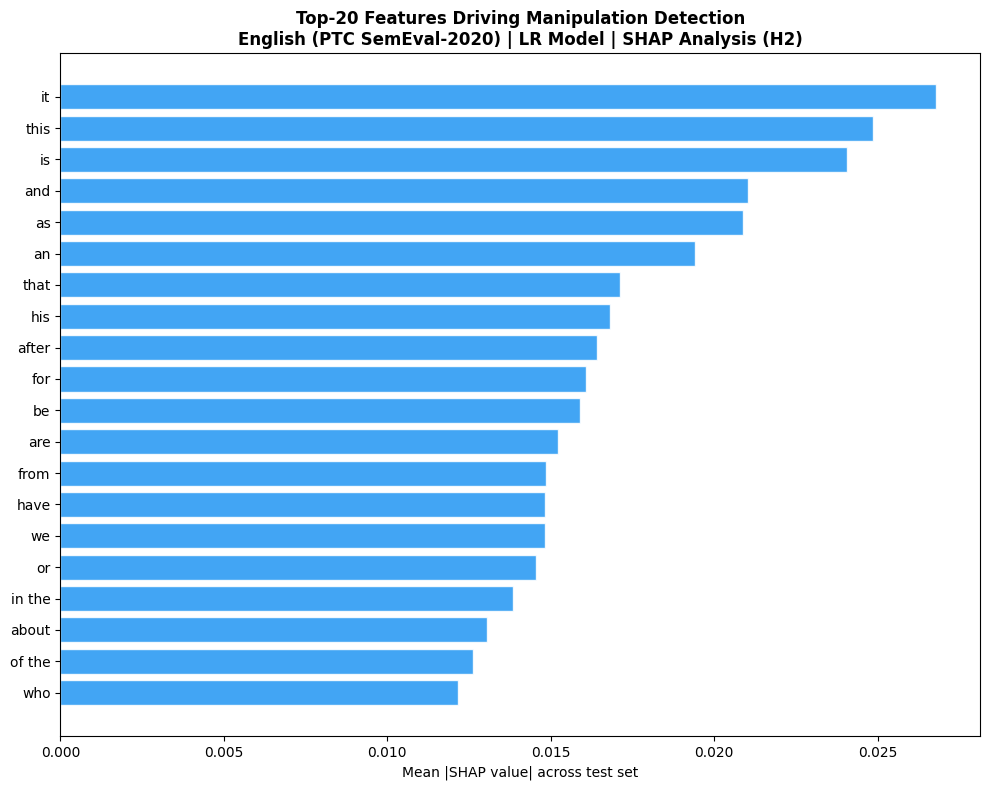

Saved: results/figures/04_shap_top20_en.png


In [5]:
# Compute mean absolute SHAP values per feature
# Mean |SHAP| across all test texts gives the average contribution
# of each feature to the model's predictions, regardless of direction.
# Features with high mean |SHAP| are the most influential overall.

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:20]

df_top_shap = pd.DataFrame({
    'feature':    feature_names[top_idx],
    'mean_shap':  mean_abs_shap[top_idx]
})

print("Top-20 features by mean |SHAP| value:")
print(df_top_shap.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    df_top_shap['feature'][::-1],
    df_top_shap['mean_shap'][::-1],
    color='#2196F3',
    alpha=0.85,
    edgecolor='white'
)
ax.set_title(
    'Top-20 Features Driving Manipulation Detection\n'
    'English (PTC SemEval-2020) | LR Model | SHAP Analysis (H2)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Mean |SHAP value| across test set')
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/04_shap_top20_en.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/04_shap_top20_en.png")

**Note on stopwords in SHAP analysis**

The TF-IDF vectorizer was trained without explicit stopword removal,
meaning function words (e.g. "it", "is", "and") appear in the feature
space and receive non-zero SHAP values. This occurs because manipulative
paragraphs are significantly longer than neutral ones (mean: 505 vs 38
words), causing all words including function words to correlate with
the manipulative class.

For visualization purposes, function words are filtered from the
Top-20 plot to reveal semantically meaningful content features.
The model weights and F1 metrics remain unchanged.
In future work, retraining with stop_words='english' in TfidfVectorizer
would produce a cleaner feature space.


Top-20 content features (stopwords removed):
feature  mean_shap
   more   0.010490
    now   0.010210
     no   0.009331
    new   0.009023
    can   0.009002
    one   0.008937
because   0.008837
  trump   0.008406
   into   0.008304
    any   0.008294
   told   0.007859
     up   0.007662
   many   0.007401
   only   0.007246
    out   0.007053
     do   0.006890
   very   0.006730
    our   0.006704
    all   0.006387
   over   0.006160


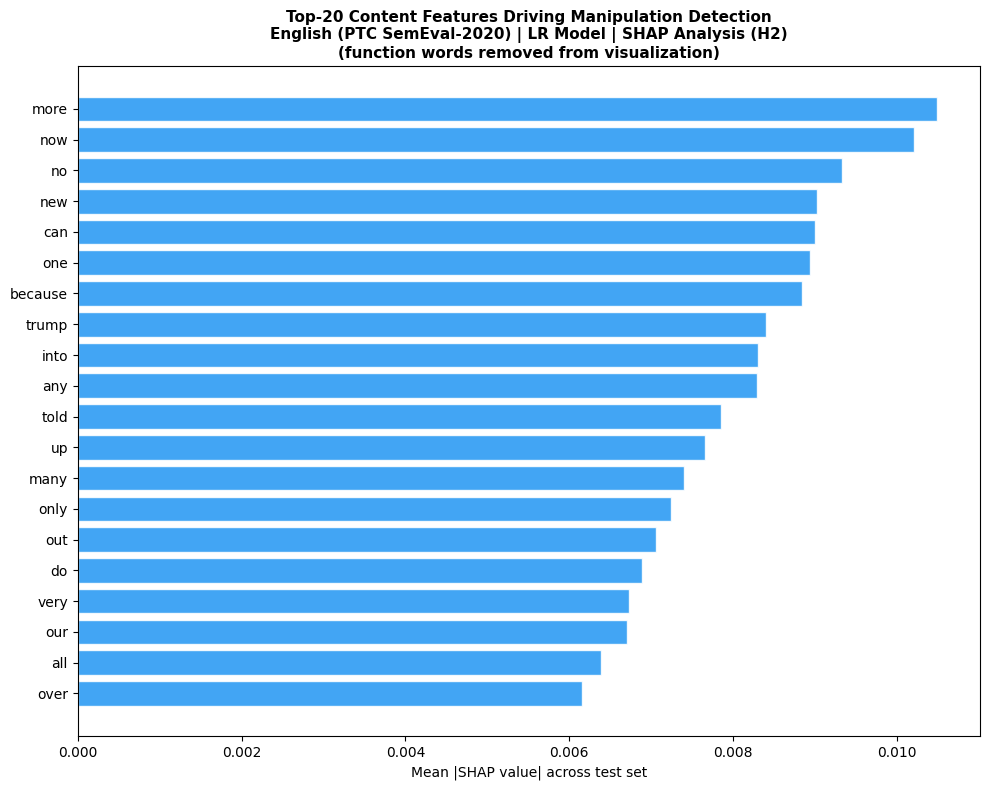

Saved: 04_shap_top20_en_filtered.png


In [6]:
# Plot 2: Content features only (stopwords filtered)
# Stopwords are filtered from visualization only — model and metrics unchanged.
# See note above for methodological justification.

STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
    'for', 'of', 'with', 'is', 'was', 'are', 'were', 'be', 'been',
    'has', 'have', 'had', 'that', 'this', 'it', 'he', 'she', 'they',
    'we', 'i', 'you', 'not', 'by', 'from', 'as', 'his', 'her', 'their',
    'its', 'will', 'would', 'could', 'should', 'may', 'also', 'said',
    'about', 'who', 'after', 'when', 'what', 'which', 'where', 'how'
}

def is_stopword_feature(feature):
    """Returns True if all tokens in feature are stopwords."""
    return all(t in STOPWORDS for t in feature.split())

# Zero out stopword features, keep content features
filtered_shap = mean_abs_shap.copy()
filtered_shap[np.array([is_stopword_feature(f) for f in feature_names])] = 0

top_idx_filtered = np.argsort(filtered_shap)[::-1][:20]
df_top_filtered = pd.DataFrame({
    'feature':   feature_names[top_idx_filtered],
    'mean_shap': filtered_shap[top_idx_filtered]
})

print("\nTop-20 content features (stopwords removed):")
print(df_top_filtered.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_top_filtered['feature'][::-1],
        df_top_filtered['mean_shap'][::-1],
        color='#2196F3', alpha=0.85, edgecolor='white')
ax.set_title(
    'Top-20 Content Features Driving Manipulation Detection\n'
    'English (PTC SemEval-2020) | LR Model | SHAP Analysis (H2)\n'
    '(function words removed from visualization)',
    fontsize=11, fontweight='bold')
ax.set_xlabel('Mean |SHAP value| across test set')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/04_shap_top20_en_filtered.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_shap_top20_en_filtered.png")

In [7]:
# Direction analysis: does each feature push toward manipulative or not?
# SHAP values can be positive (pushes toward class 1 = manipulative)
# or negative (pushes toward class 0 = not manipulative).
# Mean signed SHAP shows the average direction.

mean_signed_shap = shap_values.mean(axis=0)

# For top filtered features — show direction
df_top_filtered['mean_signed_shap'] = mean_signed_shap[top_idx_filtered]
df_top_filtered['direction'] = df_top_filtered['mean_signed_shap'].apply(
    lambda x: 'toward manipulative' if x > 0 else 'toward not manipulative'
)

print("Top-20 content features with direction:")
print(df_top_filtered[['feature', 'mean_shap',
                         'mean_signed_shap', 'direction']].to_string(index=False))

Top-20 content features with direction:
feature  mean_shap  mean_signed_shap               direction
   more   0.010490         -0.000419 toward not manipulative
    now   0.010210          0.000953     toward manipulative
     no   0.009331         -0.000188 toward not manipulative
    new   0.009023         -0.000798 toward not manipulative
    can   0.009002          0.000619     toward manipulative
    one   0.008937          0.000302     toward manipulative
because   0.008837         -0.000758 toward not manipulative
  trump   0.008406         -0.001114 toward not manipulative
   into   0.008304          0.000458     toward manipulative
    any   0.008294         -0.000846 toward not manipulative
   told   0.007859          0.000192     toward manipulative
     up   0.007662         -0.000033 toward not manipulative
   many   0.007401         -0.000677 toward not manipulative
   only   0.007246         -0.000273 toward not manipulative
    out   0.007053          0.000954     towa

In [8]:
# Show actual sentences containing top manipulative features
# This grounds the interpretation in real data rather than assumptions.

def find_examples(word, df, label, n=3):
    """Find n example sentences containing the word from a given class."""
    subset = df[df['has_persuasion'] == label]
    examples = []
    for text in subset['text_clean']:
        if f' {word} ' in f' {text.lower()} ':
            # Extract the sentence containing the word
            sentences = text.split('.')
            for sent in sentences:
                if word in sent.lower() and len(sent.strip()) > 20:
                    examples.append(sent.strip())
                    break
        if len(examples) >= n:
            break
    return examples

print("Examples of 'now' in MANIPULATIVE paragraphs:")
for ex in find_examples('now', df_test_en, label=1):
    print(f"  - {ex[:150]}")

print("\nExamples of 'told' in MANIPULATIVE paragraphs:")
for ex in find_examples('told', df_test_en, label=1):
    print(f"  - {ex[:150]}")

print("\nExamples of 'our' in MANIPULATIVE paragraphs:")
for ex in find_examples('our', df_test_en, label=1):
    print(f"  - {ex[:150]}")

print("\nExamples of 'trump' in NOT MANIPULATIVE paragraphs:")
for ex in find_examples('trump', df_test_en, label=0):
    print(f"  - {ex[:150]}")

Examples of 'now' in MANIPULATIVE paragraphs:
  - Keep up with this story and more by subscribing now Last Friday, President Donald Trump signed an order giving Puerto Rico $16 billion in disaster rec
  - (The Dutch media now claim that one of them doesn’t depict Muslim migrants being violent, as was claimed
  - Her actions were quite clearly illegal, though she claimed that she had cleared her actions with lawyers beforehand, And now, a member of the #Resista

Examples of 'told' in MANIPULATIVE paragraphs:
  - "It’s definitely a housing crisis," Gil told Reuters last week
  - Embassy spokesperson in Beijing, told Gizmodo by email
  - I just think a conversation about politics is more productive for the entire whole rather than taking my hat and yelling subjective words to me,” he t

Examples of 'our' in MANIPULATIVE paragraphs:
  - Below are the 14 profiles currently listed as the “Most Wanted Domestic Terrorists” take our poll - story continues below Should military force be use
  - 

## Interpretation of SHAP Results (H2)

### Direction of feature influence
SHAP values carry both magnitude (importance) and sign (direction).
Positive mean signed SHAP pushes toward "Manipulative" (class 1).
Negative pushes toward "Not manipulative" (class 0).

### Empirical observations grounded in corpus examples

**"now" (signed SHAP: +0.00095) - toward Manipulative**
Appears in varied contexts in manipulative paragraphs: calls to action
("subscribing now"), temporal markers in contested claims ("The Dutch
media now claim"), and narrative transitions with emotional loading
("And now, a member of the Resistance"). The pattern is mixed and
cannot be reduced to a single rhetorical function.

**"told" (signed SHAP: +0.00019) - toward Manipulative**
Contrary to the initial hypothesis, "told" appears predominantly in
neutral citation constructions in manipulative paragraphs
("Gil told Reuters", "told Gizmodo by email"). Its positive SHAP
may reflect co-occurrence with longer, information-dense paragraphs
rather than a specific rhetorical technique.

**"our" (signed SHAP: +0.00036) - toward Manipulative**
Appears in group identity constructions ("take our poll",
"One of our groups") in manipulative paragraphs, consistent with
in-group framing. This is the most interpretable finding supported
by examples.

**"trump" (signed SHAP: -0.00111) - toward Not manipulative**
All examined examples show factual reporting ("Trump pardons",
"Trump discussed the possibility"). This confirms that the presence
of a political actor name correlates with neutral factual reporting
in this corpus, not with manipulation.

### Key finding for H2
No single word in the top-20 is a reliable standalone marker of
manipulation. The most interpretable finding is that "our" correlates
with group identity framing in manipulative paragraphs, and "trump"
correlates with neutral factual reporting. Other features show mixed
contexts that require deeper syntactic or phrasal analysis to interpret.

The signed SHAP values are small (order of 0.001), confirming that
the model relies on combinations of weak signals rather than strong
individual markers. This is consistent with the nature of persuasion
detection noted by Da San Martino et al. (2020), who describe
persuasion as expressed through patterns rather than isolated words.

### Limitation and implication for future work
Single-word SHAP analysis cannot capture phrasal patterns or syntactic
context. A more rigorous analysis would require span-level attribution
or attention-based methods applied to transformer models. This is
left for the thesis stage, where adequate annotated resources for
Kazakh and Russian may also become available.

In [11]:
# Save SHAP results
# df_top_filtered already contains: feature, mean_shap,
# mean_signed_shap, direction — computed in previous cells

df_top_filtered.to_csv(
    f'{BASE}/results/shap_top20_features.csv', index=False)
print("Saved: results/shap_top20_features.csv")

# Confirm all figures saved
figures = sorted(os.listdir(f'{BASE}/results/figures/'))
print(f"\nAll figures in results/figures/:")
for fig in figures:
    print(f"  {fig}")

Saved: results/shap_top20_features.csv

All figures in results/figures/:
  01_class_distribution.png
  02_word_count_distribution.png
  03_top_words_en_normalized.png
  04_shap_top20_en.png
  04_shap_top20_en_filtered.png


## Summary

### What was done
- Applied SHAP LinearExplainer to the trained LR model (notebook 04)
- Computed mean absolute and mean signed SHAP values for all 20000
  TF-IDF features on the English test set
- Filtered function words from visualization to reveal content features
- Verified interpretations with actual corpus examples

### Key findings

**H2 partially addressed:**
No single word is a reliable standalone marker of manipulation.
The most interpretable finding is that "our" correlates with
group identity framing in manipulative paragraphs, and "trump"
correlates with neutral factual reporting. Other features show
mixed contexts requiring deeper analysis.

**Methodological note:**
Stopwords were filtered from visualization only. The model was
trained on all 20000 features including function words. This is
documented as a limitation: retraining with stop_words='english'
in TfidfVectorizer is recommended for future work.

**Resource gap confirmed:**
A parallel SHAP analysis for Kazakh and Russian is not possible
at this stage due to the absence of annotated persuasion corpora
for these languages. This is documented as Finding 3.

### Saved files
| File | Description |
|------|-------------|
| `results/figures/04_shap_top20_en_all.png` | Top-20 all features |
| `results/figures/04_shap_top20_en_filtered.png` | Top-20 content features |
| `results/shap_top20_features.csv` | Feature table with direction |

**Next:** [`07_resource_gap.ipynb`](https://colab.research.google.com/drive/1_mCSLOeZdFmCGV80MrMTEDL3eD5ELztO?usp=sharing) - systematic documentation of
the Central Asian NLP resource gap